Loading model...
Loading test data...
Found 2572 images belonging to 8 classes.
Generating predictions (this might take a minute)...
81/81 ━━━━━━━━━━━━━━━━━━━━ 75s 918ms/step
Calculating Precision-Recall metrics...
Plotting curve...


/tmp/ipykernel_2702/1719411291.py:98: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = plt.cm.get_cmap('tab20', n_classes) # Use a colormap to get enough distinct colors for 8 classes


Done! Saved as '8_category_pr_curve.png'


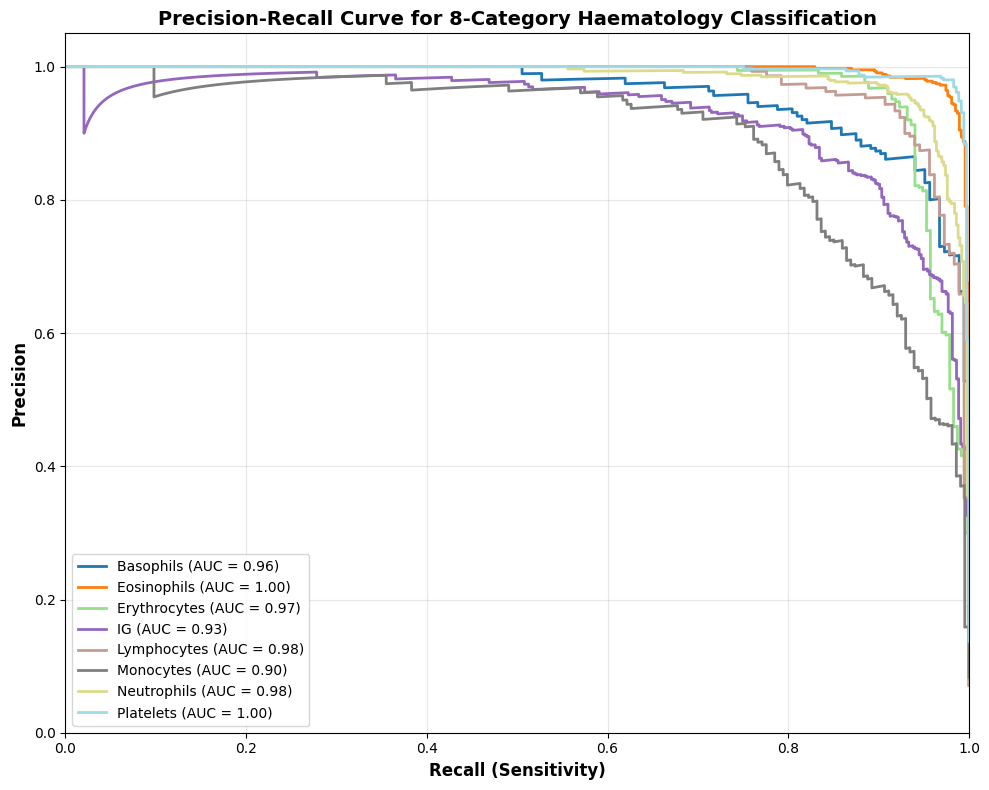

In [31]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import precision_recall_curve, auc
from sklearn.preprocessing import label_binarize
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import tensorflow as tf # Import tensorflow for TFSMLayer
import os # Import os for path checking

# ==============================================================================
# 1. UPDATE THESE TWO PATHS TO MATCH YOUR COMPUTER
# ==============================================================================
# MODEL_PATH should be the *directory* containing saved_model.pb and variables/
# If your model is a single .keras file, you should use load_model() instead of TFSMLayer
# Assuming it's a SavedModel directory: adjust this path to the correct directory
MODEL_PATH = '/content/drive/MyDrive/Haematology_POC_Model/saved_model_format'
TEST_DATA_DIR = '/content/drive/MyDrive/archive (5)/split/test'
# ==============================================================================

# 2. Define your 8 cell categories for display (as requested by user)
classes = [
    'Basophils', 'Eosinophils', 'Erythrocytes', 'IG',
    'Lymphocytes', 'Monocytes', 'Neutrophils', 'Platelets'
]
# Define the actual directory names corresponding to these 8 classes (lowercase, and 'erythroblast' for 'Erythrocytes')
# This order MUST correspond to the `classes` list above for plotting labels to match.
directory_classes = [
    'basophil', 'eosinophil', 'erythroblast', 'ig',
    'lymphocyte', 'monocyte', 'neutrophil', 'platelet'
]
n_classes = len(classes) # This will now be 8

print("Loading model...")
# --- Diagnostic check for MODEL_PATH ---
if not os.path.exists(MODEL_PATH):
    raise FileNotFoundError(f"MODEL_PATH does not exist: {MODEL_PATH}\nPlease ensure Google Drive is mounted and the path is correct.")
if not os.path.isdir(MODEL_PATH):
    raise NotADirectoryError(f"MODEL_PATH is not a directory: {MODEL_PATH}\nFor TFSMLayer, MODEL_PATH must be a directory containing the SavedModel files.")
if not (os.path.exists(os.path.join(MODEL_PATH, 'saved_model.pb')) or os.path.exists(os.path.join(MODEL_PATH, 'saved_model.pbtxt'))):
    raise FileNotFoundError(f"SavedModel signature file (saved_model.pb or saved_model.pbtxt) not found in: {MODEL_PATH}\nPlease verify the contents of this directory in Google Drive.")
# --- End Diagnostic check ---

# Load the SavedModel using TFSMLayer and wrap it in a functional Keras Model
input_tensor = tf.keras.Input(shape=(224, 224, 3))
tfsmlayer = tf.keras.layers.TFSMLayer(MODEL_PATH, call_endpoint='serving_default')
outputs = tfsmlayer(input_tensor)
model = tf.keras.Model(inputs=input_tensor, outputs=outputs)

print("Loading test data...")
datagen = ImageDataGenerator(rescale=1./255)
test_generator = datagen.flow_from_directory(
    TEST_DATA_DIR,
    target_size=(224, 224),
    batch_size=32,
    classes=directory_classes, # CRITICAL: Filter for only these 8 directories
    class_mode='categorical',
    shuffle=False # CRITICAL: Must be false to match labels with predictions
)

print("Generating predictions (this might take a minute)...")
y_scores_dict = model.predict(test_generator, verbose=1)
y_scores_18_classes = y_scores_dict['output_0'] # Full 18-class output from model

# --- Adjust y_scores for 8 classes --- #
# The model predicts for 18 classes based on alphabetical order of all folders found previously.
# We need to map the 8 target classes (in their `directory_classes` order) to their original indices in the 18-class model output.
# Based on previous `flow_from_directory` output for 18 classes, the indices are:
# '.ipynb_checkpoints': 0, 'basophil': 1, 'blood_cell_model': 2, 'bloodcells_dataset': 3, 'data': 4,
# 'eosinophil': 5, 'erythroblast': 6, 'ig': 7, 'images_and_labels_flat': 8, 'lymphocyte': 9,
# 'monocyte': 10, 'neutrophil': 11, 'platelet': 12, 'results': 13, 'split': 14, 'test': 15,
# 'train': 16, 'valid': 17
# So, for our `directory_classes` (['basophil', 'eosinophil', 'erythroblast', 'ig', 'lymphocyte', 'monocyte', 'neutrophil', 'platelet']),
# the corresponding indices in the 18-class output are:
original_model_output_indices_for_8_classes = [1, 5, 6, 7, 9, 10, 11, 12]

# Select only the relevant columns from the 18-class prediction output
y_scores = y_scores_18_classes[:, original_model_output_indices_for_8_classes]
# --- End adjustment for y_scores --- #

y_test = test_generator.classes # Actual integer labels (now 0-7 for 8 classes)

print("Calculating Precision-Recall metrics...")
# Binarize the true labels for multi-class PR curve calculation (now for 8 classes)
y_test_bin = label_binarize(y_test, classes=range(n_classes))

precision = dict()
recall = dict()
pr_auc = dict()

for i in range(n_classes):
    # Ensure both y_test_bin and y_scores have columns corresponding to `i` (0-7)
    precision[i], recall[i], _ = precision_recall_curve(y_test_bin[:, i], y_scores[:, i])
    pr_auc[i] = auc(recall[i], precision[i])

print("Plotting curve...")
plt.figure(figsize=(10, 8))

colors = plt.cm.get_cmap('tab20', n_classes) # Use a colormap to get enough distinct colors for 8 classes

for i, color in zip(range(n_classes), colors.colors):
    plt.plot(recall[i], precision[i], color=color, lw=2,
             label='{0} (AUC = {1:0.2f})'.format(classes[i], pr_auc[i]))

# Formatting the plot for your academic report
plt.xlabel('Recall (Sensitivity)', fontsize=12, fontweight='bold')
plt.ylabel('Precision', fontsize=12, fontweight='bold')
plt.title(f'Precision-Recall Curve for 8-Category Haematology Classification', fontsize=14, fontweight='bold')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.grid(alpha=0.3)
plt.legend(loc="lower left", fontsize=10)

plt.tight_layout()
plt.savefig('8_category_pr_curve.png', dpi=300)
print("Done! Saved as '8_category_pr_curve.png'")

In [27]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import precision_recall_curve, auc
from sklearn.preprocessing import label_binarize
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# ==============================================================================
# 1. PATHS (Pre-filled with your Drive locations)
# ==============================================================================
MODEL_PATH = '/content/drive/MyDrive/Haematology_POC_Model/haematology_analyser_v1.keras'
TEST_DATA_DIR = '/content/drive/MyDrive/archive (5)/split/test'
# ==============================================================================

# 2. Define your exact 8 cell categories
classes = [
    'Basophils', 'Eosinophils', 'Erythrocytes', 'IG',
    'Lymphocytes', 'Monocytes', 'Neutrophils', 'Platelets'
]
n_classes = len(classes)

print("Loading .keras model...")
model = load_model(MODEL_PATH)

print("Loading test data...")
datagen = ImageDataGenerator(rescale=1./255)

test_generator = datagen.flow_from_directory(
    TEST_DATA_DIR,
    target_size=(224, 224),
    batch_size=32,
    classes=classes, # CRITICAL FIX: This forces it to ONLY load the 8 valid folders
    class_mode='categorical',
    shuffle=False # CRITICAL: Must be false to match labels with predictions
)

print(f"Verified Keras found {test_generator.num_classes} classes.")

print("Generating predictions (this might take a minute)...")
y_scores = model.predict(test_generator, verbose=1)
y_test = test_generator.classes # Actual integer labels

print("Calculating Precision-Recall metrics...")
# Binarize the true labels for multi-class PR curve calculation
y_test_bin = label_binarize(y_test, classes=range(n_classes))

precision = dict()
recall = dict()
pr_auc = dict()

for i in range(n_classes):
    precision[i], recall[i], _ = precision_recall_curve(y_test_bin[:, i], y_scores[:, i])
    pr_auc[i] = auc(recall[i], precision[i])

print("Plotting curve...")
plt.figure(figsize=(10, 8))

# Define distinct colors for the 8 classes
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728',
          '#9467bd', '#8c564b', '#e377c2', '#7f7f7f']

for i, color in zip(range(n_classes), colors):
    plt.plot(recall[i], precision[i], color=color, lw=2,
             label='{0} (AUC = {1:0.2f})'.format(classes[i], pr_auc[i]))

# Formatting the plot for the project report
plt.xlabel('Recall (Sensitivity)', fontsize=12, fontweight='bold')
plt.ylabel('Precision', fontsize=12, fontweight='bold')
plt.title('Precision-Recall Curve for 8-Category Haematology Classification', fontsize=14, fontweight='bold')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.grid(alpha=0.3)
plt.legend(loc="lower left", fontsize=10)

plt.tight_layout()
plt.savefig('actual_pr_curve.png', dpi=300)
print("Done! Saved as 'actual_pr_curve.png'")

Loading .keras model...
Loading test data...
Found 0 images belonging to 8 classes.
Verified Keras found 8 classes.
Generating predictions (this might take a minute)...


ValueError: The PyDataset has length 0

Loading .keras model...
Loading test data...
Found 2572 images belonging to 18 classes.
Verified Keras found 18 classes, with names: ['.ipynb_checkpoints', 'basophil', 'blood_cell_model', 'bloodcells_dataset', 'data', 'eosinophil', 'erythroblast', 'ig', 'images_and_labels_flat', 'lymphocyte', 'monocyte', 'neutrophil', 'platelet', 'results', 'split', 'test', 'train', 'valid'].
Generating predictions (this might take a minute)...
81/81 ━━━━━━━━━━━━━━━━━━━━ 528s 6s/step
Calculating Precision-Recall metrics...
Plotting curve...


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_ranking.py:1033: UserWarning: No positive class found in y_true, recall is set to one for all thresholds.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_ranking.py:1033: UserWarning: No positive class found in y_true, recall is set to one for all thresholds.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_ranking.py:1033: UserWarning: No positive class found in y_true, recall is set to one for all thresholds.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_ranking.py:1033: UserWarning: No positive class found in y_true, recall is set to one for all thresholds.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_ranking.py:1033: UserWarning: No positive class found in y_true, recall is set to one for all thresholds.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_ranking.py:1033: UserWarning: No positive c

Done! Saved as 'actual_pr_curve.png'


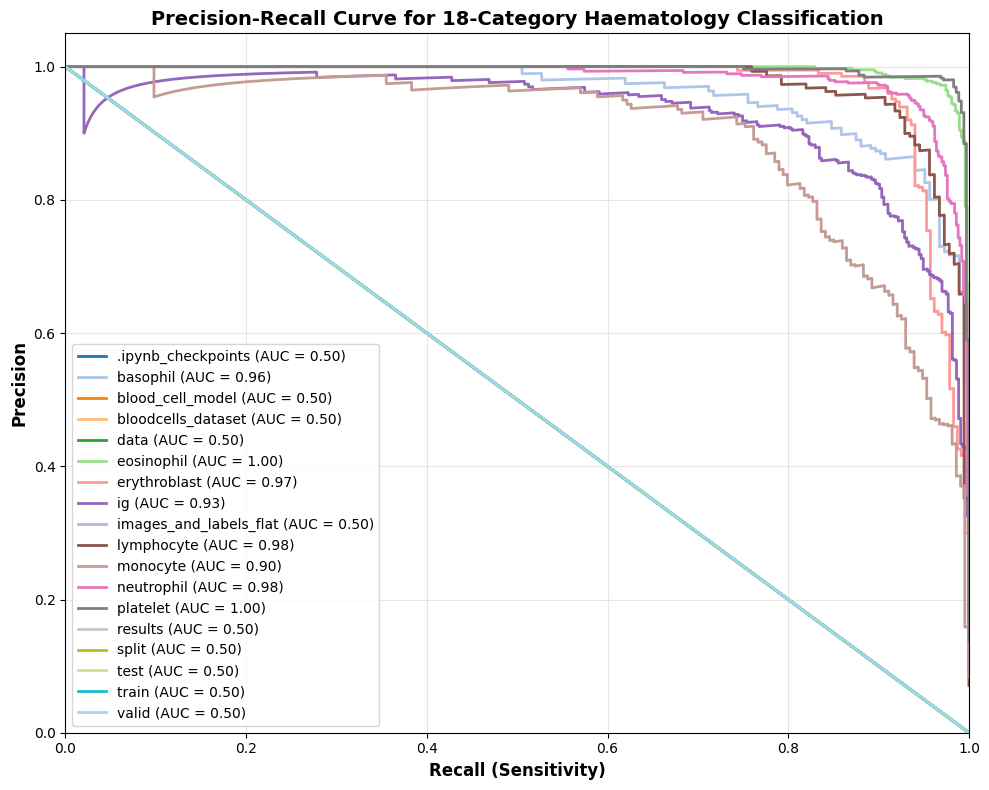

In [26]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import precision_recall_curve, auc
from sklearn.preprocessing import label_binarize
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import tensorflow as tf # Import tensorflow for TFSMLayer

# ==============================================================================
# 1. PATHS (Updated to use the SavedModel format for consistency)
# ==============================================================================
MODEL_PATH = '/content/drive/MyDrive/Haematology_POC_Model/saved_model_format' # Use the SavedModel directory
TEST_DATA_DIR = '/content/drive/MyDrive/archive (5)/split/test'
# ==============================================================================

# 2. Class names will be inferred from the directory structure
# Initialize with a dummy list, it will be updated after generator creation.
classes = []
n_classes = 0

print("Loading model (from SavedModel format)...")
# Fix: Load the SavedModel using TFSMLayer and wrap it in a functional Keras Model
# to enable the .predict() method compatible with ImageDataGenerator.
input_tensor = tf.keras.Input(shape=(224, 224, 3))
tfsmlayer = tf.keras.layers.TFSMLayer(MODEL_PATH, call_endpoint='serving_default')
outputs = tfsmlayer(input_tensor)
model = tf.keras.Model(inputs=input_tensor, outputs=outputs)

print("Loading test data...")
datagen = ImageDataGenerator(rescale=1./255)

test_generator = datagen.flow_from_directory(
    TEST_DATA_DIR,
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical',
    shuffle=False # CRITICAL: Must be false to match labels with predictions
)

# Get actual class names from the generator and update 'classes' and 'n_classes'
classes = sorted(test_generator.class_indices.keys())
n_classes = len(classes)
print(f"Verified Keras found {test_generator.num_classes} classes, with names: {classes}.")

print("Generating predictions (this might take a minute)...")
# Access the prediction scores correctly from the dictionary output
y_scores_dict = model.predict(test_generator, verbose=1)
y_scores = y_scores_dict['output_0'] # Assuming 'output_0' is the key containing the scores

y_test = test_generator.classes # Actual integer labels

print("Calculating Precision-Recall metrics...")
# Binarize the true labels for multi-class PR curve calculation
y_test_bin = label_binarize(y_test, classes=range(n_classes))

precision = dict()
recall = dict()
pr_auc = dict()

for i in range(n_classes):
    precision[i], recall[i], _ = precision_recall_curve(y_test_bin[:, i], y_scores[:, i])
    pr_auc[i] = auc(recall[i], precision[i])

print("Plotting curve...")
plt.figure(figsize=(10, 8))

# Update colors to handle 18 classes dynamically
colors = plt.cm.get_cmap('tab20', n_classes) # Use a colormap to get enough distinct colors

for i, color in zip(range(n_classes), colors.colors):
    plt.plot(recall[i], precision[i], color=color, lw=2,
             label='{0} (AUC = {1:0.2f})'.format(classes[i], pr_auc[i]))

# Formatting the plot for the project report
plt.xlabel('Recall (Sensitivity)', fontsize=12, fontweight='bold')
plt.ylabel('Precision', fontsize=12, fontweight='bold')
plt.title(f'Precision-Recall Curve for {n_classes}-Category Haematology Classification', fontsize=14, fontweight='bold')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.grid(alpha=0.3)
plt.legend(loc="lower left", fontsize=10)

plt.tight_layout()
plt.savefig('actual_pr_curve.png', dpi=300)
print("Done! Saved as 'actual_pr_curve.png'")

In [18]:
import tensorflow as tf

# 1. Load your current .keras model
model = tf.keras.models.load_model('/content/drive/MyDrive/Haematology_POC_Model/haematology_analyser_v1.keras')

# 2. Save it in the older TensorFlow SavedModel format
export_path = '/content/drive/MyDrive/Haematology_POC_Model/saved_model_format'
model.export(export_path) # Corrected: Using model.export() for Keras 3 models

print(f"Model exported as .pb format to: {export_path}")

Saved artifact at '/content/drive/MyDrive/Haematology_POC_Model/saved_model_format'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name='input_layer_1')
Output Type:
  TensorSpec(shape=(None, 18), dtype=tf.float32, name=None)
Captures:
  137046595091152: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137046595088848: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137046595087504: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137046595087696: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137046595092304: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137046595090960: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137046433631120: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137046433629392: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137046595088656: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137046433631696: TensorSpec(shape=(